In [51]:
library(data.table)
library(ggplot2)
library(ggiraph)
library(dplyr)
library(patchwork)
library(tidyr)
library(forcats)
library(ggforce)
library(circlize)
library(grid)
library(colorspace)

# Lollipop Plot
## Maximal fold changes of core postprandial responses

In [5]:
data <- fread("../results/lollipop_plot_data.csv")
head(data)

metabolite,platform_name,super_pathway,sub_pathway,significant_any_challenge,significant_fasting_pat_oltt,challenge_time,challenge,mean_response,log2_foldchange,p_value,neg_log10_p_value,abs_log2_foldchange
<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
"1,5-anhydroglucitol (1,5-ag)",Metabolon HD4 [nt-ms],Carbohydrates,"Glycolysis, Gluconeogenesis, and Pyruvate Metabolism",FALSE,FALSE,0,Fasting,-0.25972516,0.000000000,0.310763,0.5075707,0.000000000
"1,5-anhydroglucitol (1,5-ag)",Metabolon HD4 [nt-ms],Carbohydrates,"Glycolysis, Gluconeogenesis, and Pyruvate Metabolism",FALSE,FALSE,120,Fasting,-0.26698492,-0.007259760,0.310763,0.5075707,0.007259760
"1,5-anhydroglucitol (1,5-ag)",Metabolon HD4 [nt-ms],Carbohydrates,"Glycolysis, Gluconeogenesis, and Pyruvate Metabolism",FALSE,FALSE,240,Fasting,-0.08343737,0.176287792,0.310763,0.5075707,0.176287792
"1,5-anhydroglucitol (1,5-ag)",Metabolon HD4 [nt-ms],Carbohydrates,"Glycolysis, Gluconeogenesis, and Pyruvate Metabolism",FALSE,FALSE,360,Fasting,-0.15997613,0.099749023,0.310763,0.5075707,0.099749023
"1,5-anhydroglucitol (1,5-ag)",Metabolon HD4 [nt-ms],Carbohydrates,"Glycolysis, Gluconeogenesis, and Pyruvate Metabolism",FALSE,FALSE,480,Fasting,-0.07772536,0.181999794,0.310763,0.5075707,0.181999794
"1,5-anhydroglucitol (1,5-ag)",Metabolon HD4 [nt-ms],Carbohydrates,"Glycolysis, Gluconeogenesis, and Pyruvate Metabolism",FALSE,FALSE,600,Fasting,-0.26662788,-0.006902722,0.310763,0.5075707,0.006902722


In [7]:
process_metabolite_data <- function(data) {
  
  # Filter out metabolites from "In-house biochemistry [chem.]"
  filtered_data <- data %>%
    filter(significant_fasting_pat_oltt == TRUE) %>%
    filter(platform_name != "In-house biochemistry [chem.]") %>%
    mutate(metabolite = ifelse(platform_name == "Biocrates p150 [t-ms]", paste0(metabolite, "ᵇ"), metabolite))

  head(filtered_data)
  
  # Create a mapping of metabolite to sub_pathway (excluding Biocrates metabolites)
  sub_pathway_lookup <- filtered_data %>%
    filter(!grepl("\u1d47$", metabolite)) %>%
    select(metabolite, sub_pathway) %>%
    distinct()
  
  # Ensure Biocrates metabolites inherit the correct sub_pathway from their non-Biocrates counterparts
  filtered_data <- filtered_data %>%
    mutate(metabolite_base = gsub("\u1d47$", "", metabolite)) %>%
    left_join(sub_pathway_lookup, by = c("metabolite_base" = "metabolite")) %>%
    mutate(sub_pathway = coalesce(sub_pathway.y, sub_pathway.x)) %>%
    select(-sub_pathway.x, -sub_pathway.y, -metabolite_base)
  
  # Count the number of unique combinations of metabolite and platform
  num_total <- uniqueN(data[, .(metabolite, platform_name)])
  num_filtered <- uniqueN(filtered_data[, .(metabolite)])
  
  # Print the results nicely formatted
  cat(sprintf("Nr. of metabolites from all platforms: %d\n", num_total))
  cat(sprintf("Nr. of filtered metabolites: %d\n", num_filtered))
  
  # Summarize and group data
  processed_data <- filtered_data %>%
    group_by(metabolite, super_pathway, sub_pathway, challenge) %>%
    summarise(
      neg_log10_p_value = unique(neg_log10_p_value),
      max_abs_log2_fc = log2_foldchange[which.max(abs_log2_foldchange)],  # Preserve sign
      .groups = 'drop'
    ) %>%
    arrange(super_pathway, sub_pathway, metabolite)
  
  return(processed_data)
}

processed_data <- process_metabolite_data(data)

processed_data$metabolite <- factor(
    processed_data$metabolite, 
    levels = rev(unique(processed_data$metabolite))
) # Reverse the order

head(processed_data)

Nr. of metabolites from all platforms: 637
Nr. of filtered metabolites: 101


metabolite,super_pathway,sub_pathway,challenge,neg_log10_p_value,max_abs_log2_fc
<fct>,<chr>,<chr>,<chr>,<dbl>,<dbl>
alanine,Amino Acids,Alanine and Aspartate Metabolism,Fasting,5.174402,-0.9778507
alanine,Amino Acids,Alanine and Aspartate Metabolism,OLTT,9.444742,0.9194333
alanine,Amino Acids,Alanine and Aspartate Metabolism,PAT,11.876119,1.2608775
n-acetylglutamate,Amino Acids,Glutamate Metabolism,Fasting,8.139508,0.6707372
n-acetylglutamate,Amino Acids,Glutamate Metabolism,OLTT,22.292167,1.8782170
n-acetylglutamate,Amino Acids,Glutamate Metabolism,PAT,10.638881,1.1383472


In [9]:
# Count unique metabolites per super_pathway
metabolite_counts <- processed_data %>%
  distinct(metabolite, super_pathway) %>%  # Keep unique metabolite-super_pathway pairs
  count(super_pathway)  # Count occurrences per class

metabolite_counts

super_pathway,n
<chr>,<int>
Amino Acids,27
Carbohydrates,1
Cofactors and Vitamins,1
Energy,3
Lipids,57
Nucleotides,2
Peptides,2
Xenobiotics,8


In [11]:
# Determine metabolite direction across all challenges
direction_super_summary <- processed_data %>%
  group_by(metabolite, super_pathway) %>%
  summarise(
    direction = case_when(
      all(max_abs_log2_fc > 0) ~ "↑",
      all(max_abs_log2_fc < 0) ~ "↓",
      TRUE ~ "↑↓"
    ),
    .groups = "drop"
  )

# Count occurrences per super_pathway
metabolite_counts <- direction_super_summary %>%
  count(super_pathway, direction) %>%
  tidyr::pivot_wider(names_from = direction, values_from = n, values_fill = 0)

# Print the result
metabolite_counts

super_pathway,↑,↑↓,↓
<chr>,<int>,<int>,<int>
Amino Acids,5,19,3
Carbohydrates,0,1,0
Cofactors and Vitamins,0,1,0
Energy,2,1,0
Lipids,21,34,2
Nucleotides,0,2,0
Peptides,0,1,1
Xenobiotics,0,6,2


In [13]:
# Determine metabolite direction across all challenges
direction_sub_summary <- processed_data %>%
  group_by(metabolite, super_pathway, sub_pathway) %>%
  summarise(
    direction = case_when(
      all(max_abs_log2_fc > 0) ~ "↑",
      all(max_abs_log2_fc < 0) ~ "↓",
      TRUE ~ "↑↓"
    ),
    .groups = "drop"
  )

# Count occurrences per super_pathway and sub_pathway
metabolite_counts <- direction_sub_summary %>%
  count(super_pathway, sub_pathway, direction) %>%
  tidyr::pivot_wider(names_from = direction, values_from = n, values_fill = 0)

# Print the result
metabolite_counts

super_pathway,sub_pathway,↑↓,↑,↓
<chr>,<chr>,<int>,<int>,<int>
Amino Acids,Alanine and Aspartate Metabolism,1,0,0
Amino Acids,Glutamate Metabolism,0,1,0
Amino Acids,"Glycine, Serine and Threonine Metabolism",0,1,0
Amino Acids,Histidine Metabolism,1,0,0
Amino Acids,"Leucine, Isoleucine and Valine Metabolism",4,2,0
Amino Acids,"Methionine, Cysteine, SAM and Taurine Metabolism",1,1,0
Amino Acids,Phenylalanine and Tyrosine Metabolism,5,0,0
Amino Acids,Tryptophan Metabolism,3,0,3
Amino Acids,Urea cycle; Arginine and Proline Metabolism,3,0,0


In [15]:
# Determine metabolite direction across all challenges
direction_challenge_summary <- processed_data %>%
  group_by(metabolite, super_pathway, sub_pathway, challenge) %>%
  summarise(
    direction = case_when(
      all(max_abs_log2_fc > 0) ~ "↑",
      all(max_abs_log2_fc < 0) ~ "↓",
      TRUE ~ "↑↓"
    ),
    .groups = "drop"
  )

# Count occurrences per super_pathway, sub_pathway, and challenge
metabolite_counts <- direction_challenge_summary %>%
  count(super_pathway, sub_pathway, challenge, direction) %>%
  tidyr::pivot_wider(names_from = direction, values_from = n, values_fill = 0)

# Print the result
metabolite_counts

super_pathway,sub_pathway,challenge,↓,↑
<chr>,<chr>,<chr>,<int>,<int>
Amino Acids,Alanine and Aspartate Metabolism,Fasting,1,0
Amino Acids,Alanine and Aspartate Metabolism,OLTT,0,1
Amino Acids,Alanine and Aspartate Metabolism,PAT,0,1
Amino Acids,Glutamate Metabolism,Fasting,0,1
Amino Acids,Glutamate Metabolism,OLTT,0,1
Amino Acids,Glutamate Metabolism,PAT,0,1
Amino Acids,"Glycine, Serine and Threonine Metabolism",Fasting,0,1
Amino Acids,"Glycine, Serine and Threonine Metabolism",OLTT,0,1
Amino Acids,"Glycine, Serine and Threonine Metabolism",PAT,0,1


In [17]:
# Determine metabolite direction per challenge
direction_summary <- processed_data %>%
  group_by(metabolite, super_pathway, sub_pathway, challenge) %>%
  summarise(
    direction = case_when(
      all(max_abs_log2_fc > 0) ~ "↑",
      all(max_abs_log2_fc < 0) ~ "↓",
      TRUE ~ "↑↓"
    ),
    .groups = "drop"
  )

# Count occurrences per super_pathway, sub_pathway, and challenge
metabolite_counts <- direction_summary %>%
  count(super_pathway, sub_pathway, challenge, direction) %>%
  tidyr::pivot_wider(names_from = c(challenge, direction), values_from = n, values_fill = 0)

# Define the desired column order
desired_order <- c("super_pathway", "sub_pathway", 
                   "Fasting_↑", "PAT_↑", "OLTT_↑", 
                   "Fasting_↓", "PAT_↓", "OLTT_↓")

# Reorder columns
metabolite_counts <- metabolite_counts %>%
  select(all_of(desired_order))

# Print the result
metabolite_counts


super_pathway,sub_pathway,Fasting_↑,PAT_↑,OLTT_↑,Fasting_↓,PAT_↓,OLTT_↓
<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>
Amino Acids,Alanine and Aspartate Metabolism,0,1,1,1,0,0
Amino Acids,Glutamate Metabolism,1,1,1,0,0,0
Amino Acids,"Glycine, Serine and Threonine Metabolism",1,1,1,0,0,0
Amino Acids,Histidine Metabolism,0,0,1,1,1,0
Amino Acids,"Leucine, Isoleucine and Valine Metabolism",5,6,3,1,0,3
Amino Acids,"Methionine, Cysteine, SAM and Taurine Metabolism",2,1,2,0,1,0
Amino Acids,Phenylalanine and Tyrosine Metabolism,3,2,3,2,3,2
Amino Acids,Tryptophan Metabolism,1,3,1,5,3,5
Amino Acids,Urea cycle; Arginine and Proline Metabolism,0,2,2,3,1,1


In [19]:
# Assign colors for super_pathways
super_pathway_colors <- c(
  "Amino Acids" = "#d62728",
  "Carbohydrates" = "#7f7f7f",
  "Cofactors and Vitamins" = "#9467bd",
  "Energy" = "#8c564b",
  "Lipids" = "#ba8e23",
  "Nucleotides" = "#e377c2",
  "Peptides" = "#2ca02c",
  "Xenobiotics" = "#1f77b4"
)

# Assign colors for challenges
challenge_colors <- c(
  "Fasting" = "#e55050",
  "PAT" = "#6160f2",
  "OLTT" = "#ba8e23"
)

## All Metabolite Classes

### Legend on the top

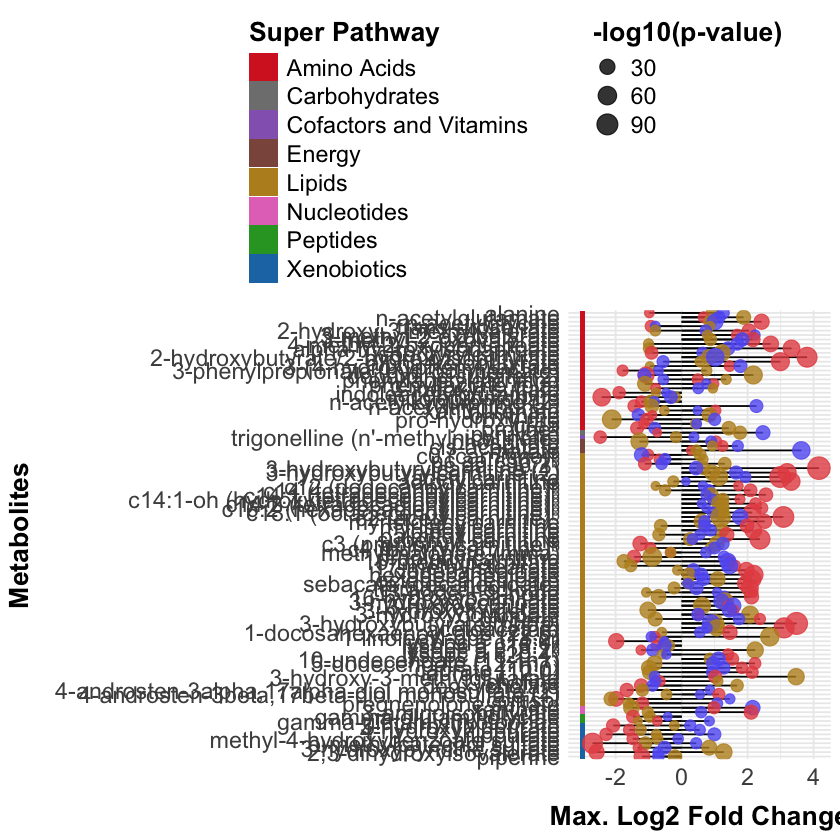

In [21]:
ggplot(processed_data, aes(x = max_abs_log2_fc, y = metabolite)) +
  # Classification bar (super_pathway)
  geom_tile(aes(x = -3, fill = super_pathway), width = 0.15, height = 1) +  
  scale_fill_manual(values = super_pathway_colors, name = "Super Pathway") +
  # Lollipop elements
  geom_segment(aes(xend = 0, yend = metabolite), color = "black") +
  geom_point(aes(color = challenge, size = neg_log10_p_value), alpha = 0.8) +
  scale_color_manual(
      values = challenge_colors,
      labels = c("Fasting" = "Fasting",
                 "PAT" = "Physical Activity",
                 "OLTT" = "Oral liquid tolerance test")
  ) +
  scale_size_continuous(range = c(2, 6)) +
  theme_minimal() +
  labs(
    x = "Max. Log2 Fold Change",
    y = "Metabolites",
    color = "Challenge",
    size = "-log10(p-value)"
  ) +
  theme(
    axis.text.x = element_text(size = 14),
    axis.text.y = element_text(size = 14),
    axis.title.x = element_text(face = "bold", size = 16, , margin = margin(t = 10)),
    axis.title.y = element_text(face = "bold", size = 16),
    legend.position = "top",  # Move legends to the top
    legend.box = "horizontal",  # Keep legends next to each other
    legend.direction = "vertical",  # Stack labels below their titles
    legend.title = element_text(face = "bold", size = 16),
    legend.text = element_text(size = 14),
    legend.spacing.x = unit(1, "cm"),  # Add more space between the legends
    #plot.margin = margin(20, 20, 20, 20)  # Add margin around the plot
  ) +
  guides(
    fill = guide_legend(order = 1, nrow = 8, title = "Super Pathway"),  # First legend
    size = guide_legend(order = 2, nrow = 3, title = "-log10(p-value)"),  # Second legend
    color = guide_legend(order = 3, nrow = 3, title = "Challenge", override.aes = list(size = 5))  # Third legend
  )

ggsave("results/fig_4_A_lollipop_plot_all_super_pathways.png", width = 18, height = 23, dpi = 300, bg = "white")


In [ ]:
ggplot(processed_data, aes(x = max_abs_log2_fc, y = metabolite)) +
  # Classification bar (super_pathway)
  geom_tile(aes(x = -50, fill = super_pathway), width = 1, height = 1) +  
  scale_fill_manual(values = super_pathway_colors, name = "Super Pathway") +
  # Lollipop elements
  geom_segment(aes(xend = 0, yend = metabolite), color = "black") +
  geom_point(aes(color = challenge, size = neg_log10_p_value), alpha = 0.8) +
  scale_color_manual(
      values = challenge_colors,
      labels = c("Fasting" = "Fasting",
                 "PAT" = "Physical Activity",
                 "OLTT" = "Oral liquid tolerance test")
  ) +
  scale_size_continuous(range = c(2, 6)) +
  theme_minimal() +
  labs(
    x = "Max. Log2 Fold Change",
    y = "Metabolites",
    color = "Challenge",
    size = "-log10(p-value)"
  ) +
  theme(
    axis.text.y = element_text(size = 12),
    axis.title.x = element_text(face = "bold", size = 14, margin = margin(t = 10)),
    axis.title.y = element_text(face = "bold", size = 14),
    legend.position = "right",  # Move legends to the right
    legend.box = "vertical",  # Stack legends vertically
    legend.title = element_text(face = "bold", size = 14),
    legend.text = element_text(size = 12),
    legend.spacing.y = unit(0.5, "cm"),  # Adjust spacing between legend items
    #plot.margin = margin(20, 20, 20, 20)  # Add margin around the plot
  ) +
  guides(
    fill = guide_legend(order = 1, title = "Super Pathway"),  
    size = guide_legend(order = 2, title = "-log10(p-value)"),  
    color = guide_legend(order = 3, title = "Challenge", override.aes = list(size = 5))  
  )

ggsave("results/fig_4_A_lollipop_plot.png", width = 15, height = 18, dpi = 300, bg = "white")


## Plots by Super_Pathway (Class)

In [45]:
# Function to generate distinct shades for sub_pathways within a given super_pathway
generate_subpathway_colors <- function(data_subset, color_choice) {
  # Define a mapping of colors to palettes
  color_palettes <- list(
    red = "Reds",
    grey = "Light Grays",
    purple = "Purp",
    brown = "Peach",
    gold = "Heat",
    rose = "PuRd",
    green = "Greens",
    blue = "Teal"
  )
  
  # Check if the provided color_choice exists in the mapping
  if (!(color_choice %in% names(color_palettes))) {
    stop("Invalid color choice. Please select from: red, grey, purple, brown, gold, rose, green, or blue.")
  }
  
  # Extract unique sub_pathways
  sub_pathways <- unique(data_subset$sub_pathway)
  
  # Determine the number of colors needed
  num_colors <- length(sub_pathways)
  
  # Select the appropriate palette
  palette <- color_palettes[[color_choice]]
  
  # Generate color shades using the selected palette
  sub_pathway_colors <- sequential_hcl(num_colors, palette = palette, rev = TRUE)
  
  # Assign colors to each sub_pathway
  named_colors <- setNames(sub_pathway_colors, sub_pathways)
  
  return(named_colors)
}


create_sub_pathway_plot <- function(data_subset, color_choice) {

    # Generate colors for the Lipid sub-pathways using the base gold color
    subpathway_colors <- generate_subpathway_colors(data_subset, color_choice)

    # Create the lollipop plot for subset categorized by sub_pathway
    ggplot(data_subset, aes(x = max_abs_log2_fc, y = metabolite)) +
      # Classification bar (sub_pathway)
      geom_tile(aes(x = -3, fill = sub_pathway), width = 0.15, height = 1) +  
      scale_fill_manual(values = subpathway_colors, name = "Sub Pathway") +
      # Lollipop elements
      geom_segment(aes(xend = 0, yend = metabolite), color = "black") +
      geom_point(aes(color = challenge, size = neg_log10_p_value), alpha = 0.8) +
      scale_color_manual(
          values = challenge_colors,
          labels = c("Fasting" = "Fasting",
                     "PAT" = "Physical Activity",
                     "OLTT" = "Oral liquid tolerance test")
      ) +
      scale_size_continuous(range = c(2, 6)) +
      theme_minimal() +
      labs(
        #title = "Categorized by Sub Pathway",
        x = "Max. Log2 Fold Change",
        y = "Metabolites",
        fill = "Sub Pathway",
        color = "Challenge",
        size = "-log10(p-value)"
      ) +
      theme(
        plot.title = element_text(face = "bold", size = 18, hjust = 0.5),
        axis.text.y = element_text(size = 12),
        axis.title.x = element_text(face = "bold", size = 14, margin = margin(t = 10)),
        axis.title.y = element_text(face = "bold", size = 14),
        legend.position = "right",  # Keep legends on the right
        legend.box = "vertical",  # Stack legends vertically
        legend.title = element_text(face = "bold", size = 14),
        legend.text = element_text(size = 12),
        legend.spacing.y = unit(0.5, "cm"),  # Adjust spacing between legend items
        # plot.margin = margin(20, 20, 20, 20)  # Add margin around the plot
      ) +
      guides(
        fill = guide_legend(order = 1, title = "Sub Pathway"),  
        size = guide_legend(order = 2, title = "-log10(p-value)"),  
        color = guide_legend(order = 3, title = "Challenge", override.aes = list(size = 5))  
      )
    
    # Save the plot
    ggsave("results/fig_4_B_lipid_subpathway_lollipop_plot_test.png", width = 15, height = 12, dpi = 300, bg = "white")

}


# Filter for metabolites belonging to the "Lipids" super_pathway
lipid_data <- processed_data %>%
  filter(super_pathway == "Lipids")

# Count unique metabolites per sub_pathway and add a total row
lipid_data %>%
  distinct(metabolite, sub_pathway) %>%  # Keep unique metabolite-sub_pathway pairs
  count(sub_pathway) %>%  # Count occurrences per class
  bind_rows(tibble(sub_pathway = "Total", n = sum(.$n)))  # Append a total row

create_sub_pathway_plot(lipid_data, "gold")

sub_pathway,n
<chr>,<int>
Carnitine Metabolism,1
Diacylphosphatidylcholine,2
Fatty Acid Metabolism (Acyl Carnitine),17
Fatty Acid Metabolism (also BCAA Metabolism),4
"Fatty Acid, Branched",2
"Fatty Acid, Dicarboxylate",5
"Fatty Acid, Monohydroxy",6
Glycerolipid Metabolism,1
Ketone Bodies,2


In [47]:
# Function to create Xenobiotics lollipop plot
xeno_create_sub_pathway_plot <- function(data_subset, color_choice) {

    # Generate colors for the Xenobiotic sub-pathways
    subpathway_colors <- generate_subpathway_colors(data_subset, color_choice)

    # Create the lollipop plot for subset categorized by sub_pathway
    p <- ggplot(data_subset, aes(x = max_abs_log2_fc, y = metabolite)) +
      # Classification bar (sub_pathway)
      geom_tile(aes(x = -3, fill = sub_pathway), width = 0.15, height = 1) +  
      scale_fill_manual(values = subpathway_colors, name = "Sub Pathway") +
      # Lollipop elements
      geom_segment(aes(xend = 0, yend = metabolite), color = "black") +
      geom_point(aes(color = challenge, size = neg_log10_p_value), alpha = 0.8) +
      scale_color_manual(
          values = challenge_colors,
          labels = c("Fasting" = "Fasting",
                     "PAT" = "Physical Activity",
                     "OLTT" = "Oral liquid tolerance test")
      ) +
      scale_size_continuous(range = c(2, 6)) +
      scale_y_discrete(expand = expansion(mult = c(0.02, 0.05)), guide = guide_axis(check.overlap = TRUE)) +  
      theme_minimal() +
      labs(
        itle = "Xenobiotics",  # Add title
        x = "Max. Log2 Fold Change",
        y = "Metabolites",
        fill = "Sub Pathway",
        color = "Challenge",
        size = "-log10(p-value)"
      ) +
      theme(
        plot.title = element_text(face = "bold", size = 18, hjust = 0.5),
        axis.text.y = element_text(size = 9),  # Reduce size to make y-axis more compact
        axis.title.x = element_text(face = "bold", size = 14, margin = margin(t = 10)),
        axis.title.y = element_text(face = "bold", size = 14),
        legend.position = "right",  # Keep legends on the right
        legend.box = "vertical",  # Stack legends vertically
        legend.title = element_text(face = "bold", size = 14),
        legend.text = element_text(size = 12),
        legend.spacing.y = unit(0.3, "cm"),  # Reduce spacing between legend items
        plot.margin = margin(10, 50, 10, 10)  # Ensure enough space for the legend
      ) +
      guides(
        fill = guide_legend(order = 1, title = "Sub Pathway"),  
        size = guide_legend(order = 2, title = "-log10(p-value)"),  
        color = guide_legend(order = 3, title = "Challenge", override.aes = list(size = 5))  
      )

    # Save the plot with limitsize = FALSE
    ggsave("results/xenobiotics_lollipop_plot_tighter.png", plot = p, width = 15, height = 5, 
           dpi = 300, bg = "white", limitsize = FALSE)
}

# Filter for metabolites belonging to the "Xenobiotics" super_pathway
xenobiotics_data <- processed_data %>%
  filter(super_pathway == "Xenobiotics")

# Count unique metabolites per sub_pathway and add a total row
xenobiotics_data %>%
  distinct(metabolite, sub_pathway) %>%  # Keep unique metabolite-sub_pathway pairs
  count(sub_pathway) %>%  # Count occurrences per class
  bind_rows(tibble(sub_pathway = "Total", n = sum(.$n)))  # Append a total row

# Create and save the Xenobiotics plot
xeno_create_sub_pathway_plot(xenobiotics_data, "blue")


sub_pathway,n
<chr>,<int>
Benzoate Metabolism,5
Chemical,1
Food Component/Plant,2
Total,8


In [57]:
# Function to generate distinct shades for sub_pathways within a given super_pathway
generate_subpathway_colors <- function(data_subset, color_choice) {
  color_palettes <- list(
    red = "Reds",
    grey = "Light Grays",
    purple = "Purp",
    brown = "Peach",
    gold = "Heat",
    rose = "PuRd",
    green = "Greens",
    blue = "Teal"
  )
  
  if (!(color_choice %in% names(color_palettes))) {
    stop("Invalid color choice. Please select from: red, grey, purple, brown, gold, rose, green, or blue.")
  }
  
  sub_pathways <- unique(data_subset$sub_pathway)
  num_colors <- length(sub_pathways)
  palette <- color_palettes[[color_choice]]
  
  sub_pathway_colors <- colorspace::sequential_hcl(num_colors, palette = palette, rev = TRUE)
  named_colors <- setNames(sub_pathway_colors, sub_pathways)
  
  return(named_colors)
}

# Function to create lollipop plots for different super_pathways
create_sub_pathway_plot <- function(data_subset, color_choice, title) {
  subpathway_colors <- generate_subpathway_colors(data_subset, color_choice)

  p <- ggplot(data_subset, aes(x = max_abs_log2_fc, y = metabolite)) +
    geom_tile(aes(x = -3, fill = sub_pathway), width = 0.15, height = 1) +  
    scale_fill_manual(values = subpathway_colors, name = "Sub Pathway") +
    geom_segment(aes(xend = 0, yend = metabolite), color = "black") +
    geom_point(aes(color = challenge, size = neg_log10_p_value), alpha = 0.8) +
    scale_color_manual(
        values = challenge_colors,
        labels = c("Fasting" = "Fasting",
                   "PAT" = "Physical Activity",
                   "OLTT" = "Oral liquid tolerance test")
    ) +
    scale_size_continuous(range = c(2, 6)) +
    theme_minimal() +
    labs(
      title = title,  # Add title
      x = "Max. Log2 Fold Change",
      y = "Metabolites",
      fill = "Sub Pathway",
      color = "Challenge",
      size = "-log10(p-value)"
    ) +
    theme(
      plot.title = element_text(face = "bold", size = 18, hjust = 0.5),  # Bold title, centered
      axis.text.y = element_text(size = 12),
      axis.title.x = element_text(face = "bold", size = 14, margin = margin(t = 10)),
      axis.title.y = element_text(face = "bold", size = 14),
      legend.position = "right",
      legend.box = "vertical",
      legend.title = element_text(face = "bold", size = 14),
      legend.text = element_text(size = 12),
      legend.spacing.y = unit(0.5, "cm")
    ) +
    guides(
      fill = guide_legend(order = 1, title = "Sub Pathway"),  
      size = guide_legend(order = 2, title = "-log10(p-value)"),  
      color = guide_legend(order = 3, title = "Challenge", override.aes = list(size = 5))  
    )

  return(p)
}

# Filter for metabolites belonging to different super_pathways
amino_acids_data <- processed_data %>% filter(super_pathway == "Amino Acids")
lipid_data <- processed_data %>% filter(super_pathway == "Lipids")
xenobiotics_data <- processed_data %>% filter(super_pathway == "Xenobiotics")

# Count the number of metabolites per super_pathway
amino_acids_count <- nrow(amino_acids_data) / 3
lipid_count <- nrow(lipid_data) / 3
xenobiotics_count <- nrow(xenobiotics_data) / 3

# Assign a base height and scale it by the number of metabolites
base_height <- 2  # Adjust this to fine-tune spacing
amino_acids_height <- base_height * (amino_acids_count / 10)
lipid_height <- base_height * (lipid_count / 10)
xenobiotics_height <- base_height * (xenobiotics_count / 10)

# Generate plots with titles
amino_acids_plot <- create_sub_pathway_plot(amino_acids_data, "red", "Amino Acids")
lipid_plot <- create_sub_pathway_plot(lipid_data, "gold", "Lipids")
xenobiotics_plot <- create_sub_pathway_plot(xenobiotics_data, "blue", "Xenobiotics")

# Combine plots with dynamic heights
combined_plot <- amino_acids_plot / 
                 lipid_plot / 
                 xenobiotics_plot + 
                 plot_layout(heights = c(amino_acids_height, lipid_height, xenobiotics_height))

# Save the adjusted plot
ggsave("results/combined_lollipop_plot.png", 
       plot = combined_plot, width = 15, 
       height = sum(c(amino_acids_height, lipid_height, xenobiotics_height)) + 2, 
       dpi = 300, bg = "white")


In [ ]:
# Filter for metabolites belonging to the "Lipids" super_pathway
lipid_data <- processed_data %>%
  filter(super_pathway == "Lipids")

# Count unique metabolites per sub_pathway and add a total row
lipid_data %>%
  distinct(metabolite, sub_pathway) %>%  # Keep unique metabolite-sub_pathway pairs
  count(sub_pathway) %>%  # Count occurrences per class
  bind_rows(tibble(sub_pathway = "Total", n = sum(.$n)))  # Append a total row

In [ ]:
# Function to generate distinct shades for sub_pathways within a given super_pathway
generate_subpathway_colors <- function(data_subset, palette = "YlOrBr") {
  # Extract unique sub_pathways
  sub_pathways <- unique(data_subset$sub_pathway)
  
  # Determine the number of colors needed
  num_colors <- length(sub_pathways)
  
  # Generate color shades using the specified palette
  sub_pathway_colors <- sequential_hcl(num_colors, palette = palette, rev = TRUE)
  
  # Assign colors to each sub_pathway
  named_colors <- setNames(sub_pathway_colors, sub_pathways)
  
  return(named_colors)
}

In [ ]:
# Generate colors for the Lipid sub-pathways using the base gold color
lipid_subpathway_colors <- generate_subpathway_colors(lipid_data)

# Print the generated color mapping
print(lipid_subpathway_colors)

In [ ]:
# Create the lollipop plot for Lipids categorized by sub_pathway
ggplot(lipid_data, aes(x = max_abs_log2_fc, y = metabolite)) +
  # Classification bar (sub_pathway)
  geom_tile(aes(x = -3, fill = sub_pathway), width = 0.15, height = 1) +  
  scale_fill_manual(values = lipid_subpathway_colors, name = "Sub Pathway") +
  # Lollipop elements
  geom_segment(aes(xend = 0, yend = metabolite), color = "black") +
  geom_point(aes(color = challenge, size = neg_log10_p_value), alpha = 0.8) +
  scale_color_manual(
      values = challenge_colors,
      labels = c("Fasting" = "Fasting",
                 "PAT" = "Physical Activity",
                 "OLTT" = "Oral liquid tolerance test")
  ) +
  scale_size_continuous(range = c(2, 6)) +
  theme_minimal() +
  labs(
    #title = "Lipids Categorized by Sub Pathway",
    x = "Max. Log2 Fold Change",
    y = "Metabolites",
    fill = "Sub Pathway",
    color = "Challenge",
    size = "-log10(p-value)"
  ) +
  theme(
    plot.title = element_text(face = "bold", size = 18, hjust = 0.5),
    axis.text.y = element_text(size = 12),
    axis.title.x = element_text(face = "bold", size = 14, margin = margin(t = 10)),
    axis.title.y = element_text(face = "bold", size = 14),
    legend.position = "right",  # Keep legends on the right
    legend.box = "vertical",  # Stack legends vertically
    legend.title = element_text(face = "bold", size = 14),
    legend.text = element_text(size = 12),
    legend.spacing.y = unit(0.5, "cm"),  # Adjust spacing between legend items
    # plot.margin = margin(20, 20, 20, 20)  # Add margin around the plot
  ) +
  guides(
    fill = guide_legend(order = 1, title = "Sub Pathway"),  
    size = guide_legend(order = 2, title = "-log10(p-value)"),  
    color = guide_legend(order = 3, title = "Challenge", override.aes = list(size = 5))  
  )

# Save the plot
ggsave("results/fig_4_B_lipids_subpathway_lollipop_plot.png", width = 15, height = 12, dpi = 300, bg = "white")
